In [9]:
import numpy as np
from qutip import *
import plotly.graph_objects as go
from tqdm import tqdm, trange
import os
from datetime import datetime
from scipy.interpolate import interp1d
from sklearn.metrics import mean_absolute_error
from joblib import Parallel, delayed

timestamp = datetime.now().strftime('%M-%S')

# Figure format for plotly
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 1120,
    'height': 450,
    'xaxis': {
        'ticks': 'inside', 'mirror': 'ticks', 'linewidth': 1.5,
        'tickwidth': 1.5, 'ticklen': 5, 'showline': True,
        'showgrid': False, 'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside', 'mirror': 'ticks', 'linewidth': 1.5,
        'tickwidth': 1.5, 'ticklen': 5, 'showline': True,
        'showgrid': False, 'zerolinecolor': 'white'
    },
    'font': {'family': 'mathjax', 'size': 30}
}

In [10]:
def get_B1(t_pi):
    return (2*np.pi/28025)*(1/(2*t_pi))

def nv_parameters(gamma_rel=0.0001, gamma_deph=0.001, power_laser=100, B1=0, theta=np.pi/2, phi=0, Bx=0.0, By=0.0, Bz=0.0, gamma_d_in=0, gamma_d_out=0):
    c = 0.7                          # NV- Laser excitation constant in MHz/uW 
    gamma_p = c * power_laser        # NV- Laser excitation rate
    gamma_0 = 10                     # NV- Radiative emission rate 
        
    gamma_s0_in = 12                 # NV- Excited 0 to singlet
    gamma_s1_in = 80                 # NV- Excited 1 to singlet
    gamma_s0_out = 3.3               # NV- Singlet to ground 0 
    gamma_s1_out = 2.4               # NV- Singlet to ground 1

    gamma_d0_in = gamma_d_in
    gamma_d1_in = gamma_d_in
    gamma_d0_out = gamma_d_out
    gamma_d1_out = gamma_d_out
    
    B1x = B1 * np.sin(theta) * np.cos(phi)
    B1y = B1 * np.sin(theta) * np.sin(phi)
    B1z = B1 * np.cos(theta)
    
    parameters = [Bx, By, Bz, gamma_rel, gamma_deph, gamma_p, gamma_0, gamma_s0_in, gamma_s1_in, gamma_s0_out, gamma_s1_out,
                  gamma_d0_in, gamma_d1_in, gamma_d0_out, gamma_d1_out, B1x, B1y, B1z]

    return parameters

In [11]:
def NV_spinNcharge(parameters, tlist, psi0, drive=-1, detuning_minus=0.0, E=0.0):
    Bx, By, Bz, gamma_rel, gamma_deph, gamma_p, gamma_0, gamma_f0, gamma_f1, gamma_s0, gamma_s1, gamma_d0_in, gamma_d1_in, gamma_d0_out, gamma_d1_out, B1x, B1y, B1z = parameters

    D = 2870          # MHz
    g = 28025         # MHz/T

    n_states = 8
    spin_states = 3
    rho = np.zeros((n_states,n_states), dtype=complex)

    # Pauli Operators
    sx = Qobj(np.block([[jmat(1,'x').full(), np.zeros((3,5))], [np.zeros((5,3)), np.eye(5)]]))
    sy = Qobj(np.block([[jmat(1,'y').full(), np.zeros((3,5))], [np.zeros((5,3)), np.eye(5)]]))
    sz = Qobj(np.block([[jmat(1,'z').full(), np.zeros((3,5))], [np.zeros((5,3)), np.eye(5)]]))
    s_plus = Qobj(np.block([[jmat(1,'+').full(), np.zeros((3,5))], [np.zeros((5,3)), np.eye(5)]]))
    s_minus = Qobj(np.block([[jmat(1,'-').full(), np.zeros((3,5))], [np.zeros((5,3)), np.eye(5)]]))

    # Transition Operators
    excitation = rho.copy(); excitation[3,0] = excitation[4,1] = excitation[5,2] = np.sqrt(gamma_p); excitation = Qobj(excitation)
    emission = rho.copy(); emission[0,3] = emission[1,4] = emission[2,5] = np.sqrt(gamma_0); emission = Qobj(emission)
    singlet_in1p = rho.copy(); singlet_in1p[6,3] = np.sqrt(gamma_f1); singlet_in1p = Qobj(singlet_in1p)
    singlet_in0 = rho.copy(); singlet_in0[6,4] = np.sqrt(gamma_f0); singlet_in0 = Qobj(singlet_in0)
    singlet_in1m = rho.copy(); singlet_in1m[6,5] = np.sqrt(gamma_f1); singlet_in1m = Qobj(singlet_in1m)
    singlet_out1p = rho.copy(); singlet_out1p[0,6] = np.sqrt(gamma_s1); singlet_out1p = Qobj(singlet_out1p)
    singlet_out0 = rho.copy(); singlet_out0[1,6] = np.sqrt(gamma_s0); singlet_out0 = Qobj(singlet_out0)
    singlet_out1m = rho.copy(); singlet_out1m[2,6] = np.sqrt(gamma_s1); singlet_out1m = Qobj(singlet_out1m)
    
    dark_in1p = rho.copy(); dark_in1p[7,3] = np.sqrt(gamma_d1_in); dark_in1p = Qobj(dark_in1p)
    dark_in0 = rho.copy(); dark_in0[7,4] = np.sqrt(gamma_d0_in); dark_in0 = Qobj(dark_in0)
    dark_in1m = rho.copy(); dark_in1m[7,5] = np.sqrt(gamma_d1_in); dark_in1m = Qobj(dark_in1m)
    dark_out1p = rho.copy(); dark_out1p[0,7] = np.sqrt(gamma_d1_out); dark_out1p = Qobj(dark_out1p)
    dark_out0 = rho.copy(); dark_out0[1,7] = np.sqrt(gamma_d0_out); dark_out0 = Qobj(dark_out0)
    dark_out1m = rho.copy(); dark_out1m[2,7] = np.sqrt(gamma_d1_out); dark_out1m = Qobj(dark_out1m)

    # Hamiltonian
    H0 = D*(sz**2 - 2/3) + g*sz*Bz + g*(sx*Bx + sy*By) + E*(sx**2 - sy**2)
    eigenenergies, _ = H0.eigenstates()
    eigenenergies = np.unique(eigenenergies)

    omega = eigenenergies[1]-eigenenergies[0]-detuning_minus if drive == -1 else eigenenergies[2]-eigenenergies[0]
    H1 = g * (sx*B1x + sy*B1y + sz*B1z) 
    H_drive = [[H1, lambda t, args: np.cos(omega * t)]]
    H = [H0] + H_drive

    c_ops = [
        np.sqrt(gamma_rel/(2*np.pi)) * s_minus, np.sqrt(gamma_rel/(2*np.pi)) * s_plus, np.sqrt(2*gamma_deph) * sz,
        excitation, emission, singlet_in1p, singlet_in0, singlet_in1m, singlet_out1p, singlet_out0, singlet_out1m,
        dark_in1p, dark_in0, dark_in1m, dark_out1p, dark_out0, dark_out1m
    ]

    expect_ops = [basis(n_states, i)*basis(n_states, i).dag() for i in range(8)]

    result = mesolve(H, psi0, tlist, c_ops, expect_ops, options={"store_final_state": True, "nsteps": 1e5, "store_states": True})
    return result.expect, result.final_state, result.states

In [12]:
def initialize(psi0, gamma_rel=0.0001, gamma_deph=0.001, power_laser=100, B1=0, duration=5, drive=-1, t_steps=1001, gamma_d_in=0, gamma_d_out=0):
    parameters = nv_parameters(gamma_rel, gamma_deph, power_laser, B1, gamma_d_in=gamma_d_in, gamma_d_out=gamma_d_out)
    tlist = np.linspace(0, duration, t_steps)
    populations, _, psi_list = NV_spinNcharge(parameters, tlist, psi0, drive)
    return populations, psi_list, tlist   

def evolve(psi0, gamma_rel=0.0001, gamma_deph=0.001, power_laser=0, duration=0.1, drive=-1, t_steps=101, spacing_type='linspace', gamma_d_in=0, gamma_d_out=0, t_start=0.02):
    parameters = nv_parameters(gamma_rel, gamma_deph, power_laser, gamma_d_in=gamma_d_in, gamma_d_out=gamma_d_out)
    tlist = np.geomspace(t_start, duration, t_steps) if spacing_type == 'geomspace' else np.linspace(0, duration, t_steps)
    populations, _, psi_list = NV_spinNcharge(parameters, tlist, psi0, drive)
    return populations, psi_list, tlist  

def read(psi0, gamma_rel=0.0001, gamma_deph=0.001, power_laser=100, B1=0, duration=5, drive=-1, t_steps=1001, gamma_d_in=0, gamma_d_out=0):
    parameters = nv_parameters(gamma_rel, gamma_deph, power_laser, B1, gamma_d_in=gamma_d_in, gamma_d_out=gamma_d_out)
    psi0 = Qobj(qdiags(psi0.diag(), offsets=0), dims=psi0.dims)  
    tlist = np.linspace(0, duration, t_steps)
    populations, _, psi_list = NV_spinNcharge(parameters, tlist, psi0, drive)
    return populations, psi_list, tlist  

def count(populations, tlist, duration=0.5, gamma_0=63, collection=0.01):
    index = np.argwhere(tlist <= duration)[-1][0]
    n = np.mean(np.array(np.real(populations[3:6])[:,:index+1]))
    return n * duration * gamma_0 * collection

def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    data_shape = data['avg_data'].shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        ref_samples = np.mean(np.reshape(data['avg_data'][::2], (steps, samples)), axis=1)
        sig_samples = np.mean(np.reshape(data['avg_data'][1::2], (steps, samples)), axis=1)
    else:
        sig_samples = np.mean(np.reshape(data['avg_data'][::2], (steps, samples)), axis=1)
        ref_samples = np.mean(np.reshape(data['avg_data'][1::2], (steps, samples)), axis=1)

    return time, sig_samples / ref_samples, ref_samples, sig_samples

In [24]:
def compute_signal(args):
    params, psi0, power_array, init_array, gamma_d_in, gamma_d_out, gamma_rel, gamma_deph, read_window, dark_time, dark_steps = args
    p, t, d1, d2 = params

    _, psi1, _ = initialize(psi0, power_laser=power_array[p], duration=init_array[t], t_steps=51,
                            gamma_rel=gamma_rel, gamma_deph=gamma_deph, gamma_d_in=gamma_d_in[d1], gamma_d_out=gamma_d_out[d2])

    _, psi2, t_t1 = evolve(psi1[-1], duration=dark_time, t_steps=dark_steps, spacing_type='geomspace', t_start=0.02, 
                           gamma_rel=gamma_rel, gamma_deph=gamma_deph, gamma_d_in=gamma_d_in[d1], gamma_d_out=gamma_d_out[d2])

    signal_local = np.zeros(dark_steps)
    for i in range(len(psi2)):
        pops3, _, t_read = read(psi2[i], power_laser=power_array[p], duration=read_window, t_steps=51,
                                gamma_rel=gamma_rel, gamma_deph=gamma_deph, gamma_d_in=gamma_d_in[d1], gamma_d_out=gamma_d_out[d2])
        signal_local[i] = count(pops3, t_read, duration=read_window)

    return (p, t, d1, d2, t_t1, signal_local)

psi0 = (1/6)*ket2dm(basis(8, 0)) + (1/6)*ket2dm(basis(8, 1)) + (1/6)*ket2dm(basis(8, 2)) + (1/2)*ket2dm(basis(8, 7))

# Parameter Grids
power_array, init_array = np.array([5]), np.array([15])
gamma_d_in, gamma_d_out = np.geomspace(0.00001,1,10), np.geomspace(0.00001,1,10)
dark_steps = 51

signal_array = np.zeros((len(power_array), len(init_array), len(gamma_d_in), len(gamma_d_out), dark_steps))
t_array = np.zeros_like(signal_array)

params_list = [(p, t, d1, d2) for p in range(len(power_array)) for t in range(len(init_array)) for d1 in range(len(gamma_d_in)) for d2 in range(len(gamma_d_out))]
args_list = [(p, psi0, power_array, init_array, gamma_d_in, gamma_d_out, 0.02, 0.0, 0.5, 100, dark_steps) for p in params_list]

if __name__ == "__main__":
    results = Parallel(n_jobs=-1)(delayed(compute_signal)(arg) for arg in tqdm(args_list))
    
    for p, t, d1, d2, t_t1, signal_local in results:
        t_array[p, t, d1, d2, :] = t_t1
        signal_array[p, t, d1, d2, :] = signal_local
    
    os.makedirs('data', exist_ok=True)
    np.savez_compressed(f'data/5uW_15us_readout_0.5us_gamma_d_in_0_dark_halfPop.npz', signal_array=signal_array, t_array=t_array)
    print("Simulation Complete and Saved.")

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:35<00:00,  1.04it/s]


Simulation Complete and Saved.


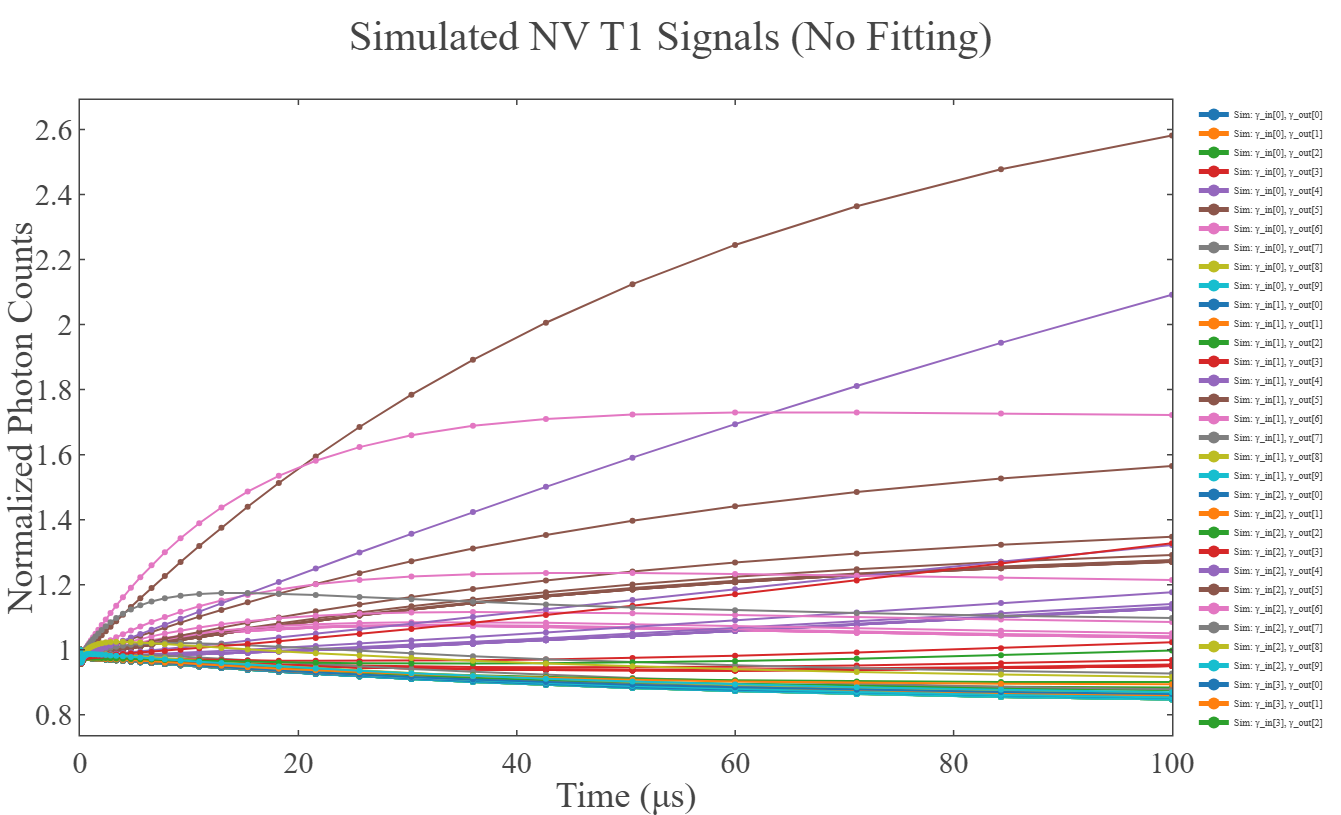

In [25]:
# Load simulation data
sim_data = np.load(f'data/5uW_15us_readout_0.5us_gamma_d_in_0_dark_halfPop.npz')

# Squeeze removes all dimensions of size 1
sim_t_squeezed = np.squeeze(sim_data['t_array']) * 1e3 
sim_sig_squeezed = np.squeeze(sim_data['signal_array'])

# Pad dimensions to ensure we always have exactly 3D arrays: (d_in, d_out, steps)
# This dynamically handles if both are scalars, one is a scalar, or both are arrays
while sim_sig_squeezed.ndim < 3:
    sim_t_squeezed = np.expand_dims(sim_t_squeezed, axis=0)
    sim_sig_squeezed = np.expand_dims(sim_sig_squeezed, axis=0)

fig_sim = go.Figure()

# Plot all simulated curves
for i in range(sim_sig_squeezed.shape[0]):
    for j in range(sim_sig_squeezed.shape[1]):
        sim_time = sim_t_squeezed[i, j, :]
        sim_signal = sim_sig_squeezed[i, j, :]
        
        # Normalize signal to the first data point
        sim_signal_normalized = sim_signal / sim_signal[0] if sim_signal[0] != 0 else sim_signal
        
        fig_sim.add_scatter(
            x=sim_time / 1000, 
            y=sim_signal_normalized, 
            mode='lines+markers', 
            name=f'Sim: γ_in[{i}], γ_out[{j}]',
            line=dict(width=2)
        )

fig_sim.update_layout(
    template=fig_template, 
    height=800, width=1600, 
    xaxis=dict(title="Time (μs)", range=[0, 100]), 
    yaxis=dict(title="Normalized Photon Counts"),
    title="Simulated NV T1 Signals (No Fitting)",
    legend=dict(itemsizing='constant', font=dict(size=10), bgcolor='rgba(255,255,255,0.8)')
)
fig_sim.show()

Global Minimum MAE: γ_in[0], γ_out[0] = 0.043555


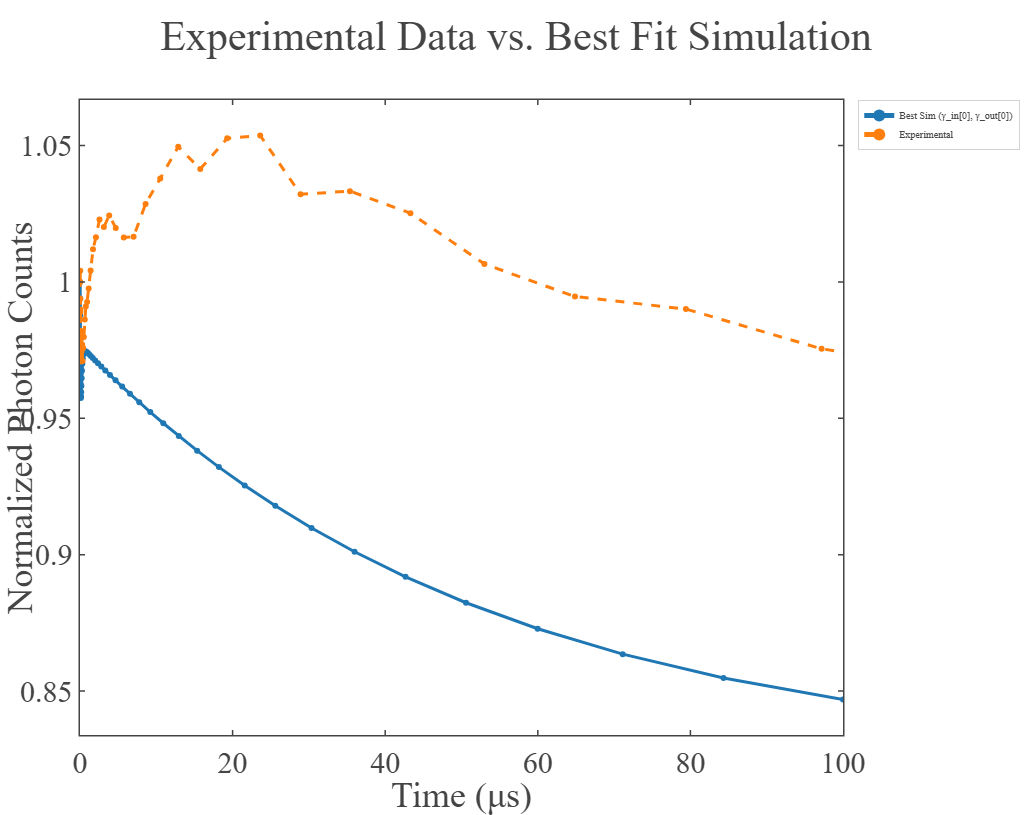

In [17]:
# Load Experimental Data
exp_data = np.load(r"D:\Atanu\Atanu_Github\T1_measurements\codes\data\2025\May_12\arranging_datas_with_power\5uW\l_15.0us\[17_22_10]_1.0us.npz")
time_axis, signal_photon, _, _ = data_to_time_signal(exp_data, 2000, first='signal')
time_axis, signal_photon = time_axis[1:], signal_photon[1:]

# Interpolation and MAE Setup
std_t_array = np.array([0.02, 0.05, 0.1, 0.2, 0.51, 2.5, 5, 10, 20, 50, 100]) * 1e3
exp_values_at_std = interp1d(time_axis, signal_photon, bounds_error=False, fill_value="extrapolate")(std_t_array)
mae_array = np.zeros((sim_sig_squeezed.shape[0], sim_sig_squeezed.shape[1]))

for i in range(sim_sig_squeezed.shape[0]):
    for j in range(sim_sig_squeezed.shape[1]):
        sim_time = sim_t_squeezed[i, j, :]
        sim_signal = sim_sig_squeezed[i, j, :]
        sim_signal_normalized = sim_signal / sim_signal[0] if sim_signal[0] != 0 else sim_signal
        
        sim_values_at_std = interp1d(sim_time, sim_signal_normalized, bounds_error=False, fill_value="extrapolate")(std_t_array)
        mae_array[i, j] = np.mean(np.abs(sim_values_at_std - exp_values_at_std))

# Find Best Fit
min_i, min_j = np.unravel_index(np.argmin(mae_array), mae_array.shape)
print(f"Global Minimum MAE: γ_in[{min_i}], γ_out[{min_j}] = {mae_array[min_i, min_j]:.6f}")

# Plotting Global Minimum against Experimental Data
best_sim_time = sim_t_squeezed[min_i, min_j, :]
best_sim_signal = sim_sig_squeezed[min_i, min_j, :]
best_sim_signal_norm = best_sim_signal / best_sim_signal[0] if best_sim_signal[0] != 0 else best_sim_signal
exp_signal_norm = signal_photon / signal_photon[0] if signal_photon[0] != 0 else signal_photon

fig_fit = go.Figure()
fig_fit.add_scatter(x=best_sim_time / 1000, y=best_sim_signal_norm, mode='lines+markers', line=dict(width=3), name=f'Best Sim (γ_in[{min_i}], γ_out[{min_j}])')
fig_fit.add_scatter(x=time_axis / 1000, y=exp_signal_norm, mode='lines+markers', name='Experimental', marker=dict(symbol='circle', size=6), line=dict(width=3, dash='dash'))

fig_fit.update_layout(
    template=fig_template, 
    height=800, width=1600, 
    xaxis=dict(title="Time (μs)", range=[0, 100]), 
    yaxis=dict(title="Normalized Photon Counts"),
    title="Experimental Data vs. Best Fit Simulation",
    legend=dict(itemsizing='constant', font=dict(size=10), bgcolor='rgba(255,255,255,0.8)', bordercolor="LightGray", borderwidth=1)
)
fig_fit.show()